# Predicting Website Conversion from User Behavior  
## A Systems Engineering Approach to Intent Modeling

**Authors:** Muhammad Bilal Yousuf and Jaimin Sunil Sharma

This notebook implements the full project pipeline proposed in the team proposal:
- Exploratory Data Analysis (EDA)
- Preprocessing
- Class imbalance handling with **SMOTE**
- Baseline model: **Logistic Regression**
- Nonlinear models: **Random Forest** and **XGBoost**
- Evaluation with **F1-score**, **AUPRC**, and **ROC-AUC**
- **Ablation study** for behavioral vs. behavioral + temporal features
- **SHAP** interpretability for the best model

### Expected dataset
This notebook is designed for the **UCI Online Shoppers Purchasing Intention Dataset**.

### Colab usage
1. Run the install cell.
2. Upload `online_shoppers_intention.csv` when prompted.
3. Run all cells from top to bottom.

In [11]:
# Install required libraries (Colab)
!pip -q install imbalanced-learn xgboost shap

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
import shap

SEED = 42
np.random.seed(SEED)

## 1. Upload and load the dataset
If the file is already in your Colab session, you can skip the upload prompt and just load it from the current directory.

In [13]:
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention (1).csv


In [14]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Basic inspection
These cells help confirm the dataset structure, class imbalance, and data types.

In [15]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Shape: (12330, 18)

Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues        

In [16]:
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values per column:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [17]:
# Standardize target column to integer if needed
if df["Revenue"].dtype == object:
    df["Revenue"] = df["Revenue"].astype(str).str.strip().str.lower().map({"true": 1, "false": 0})
elif str(df["Revenue"].dtype).startswith("bool"):
    df["Revenue"] = df["Revenue"].astype(int)

print(df["Revenue"].value_counts(dropna=False))
print(df["Revenue"].value_counts(normalize=True).rename("proportion"))

Revenue
0    10422
1     1908
Name: count, dtype: int64
Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)
This section supports the proposal's assumptions about class imbalance, behavioral signals, and temporal effects.

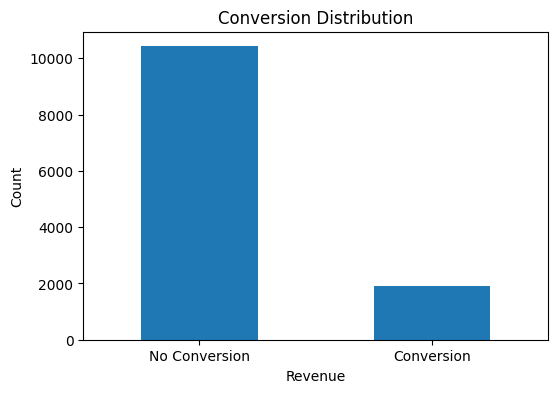

In [18]:
plt.figure(figsize=(6,4))
df["Revenue"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["No Conversion", "Conversion"], rotation=0)
plt.title("Conversion Distribution")
plt.ylabel("Count")
plt.show()

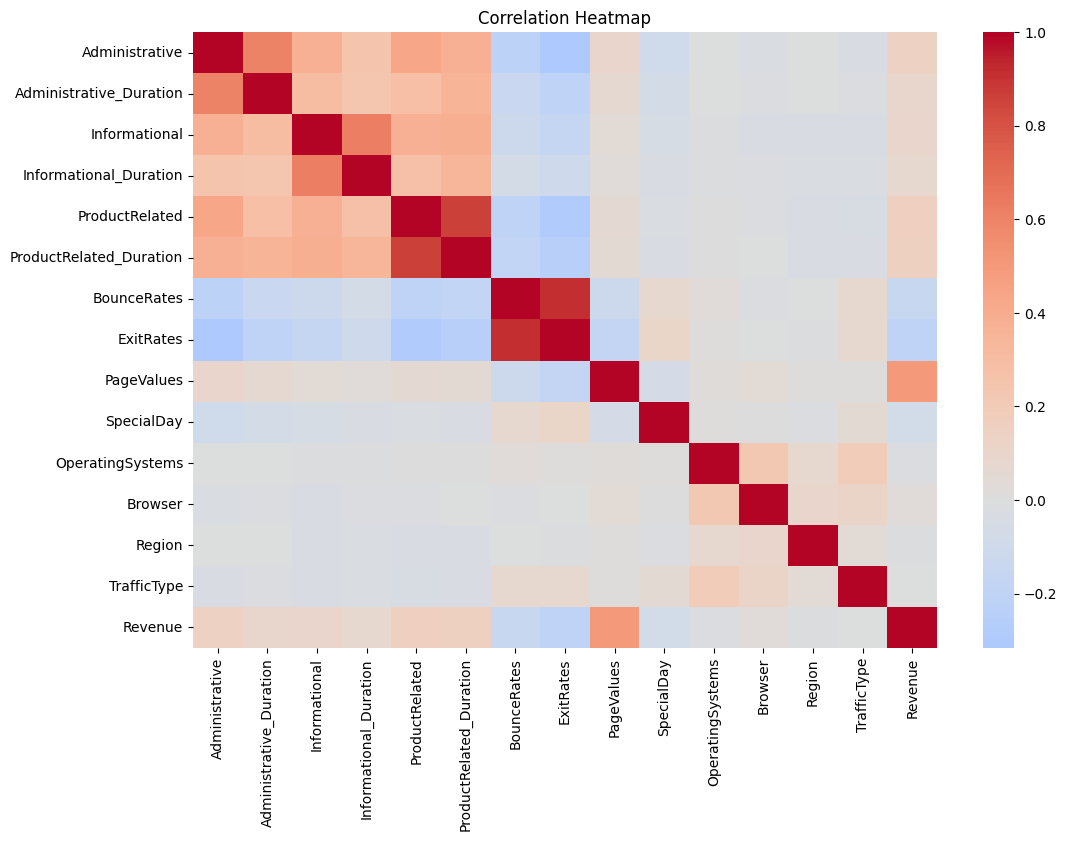

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
corr = numeric_df.corr()
import seaborn as sns
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

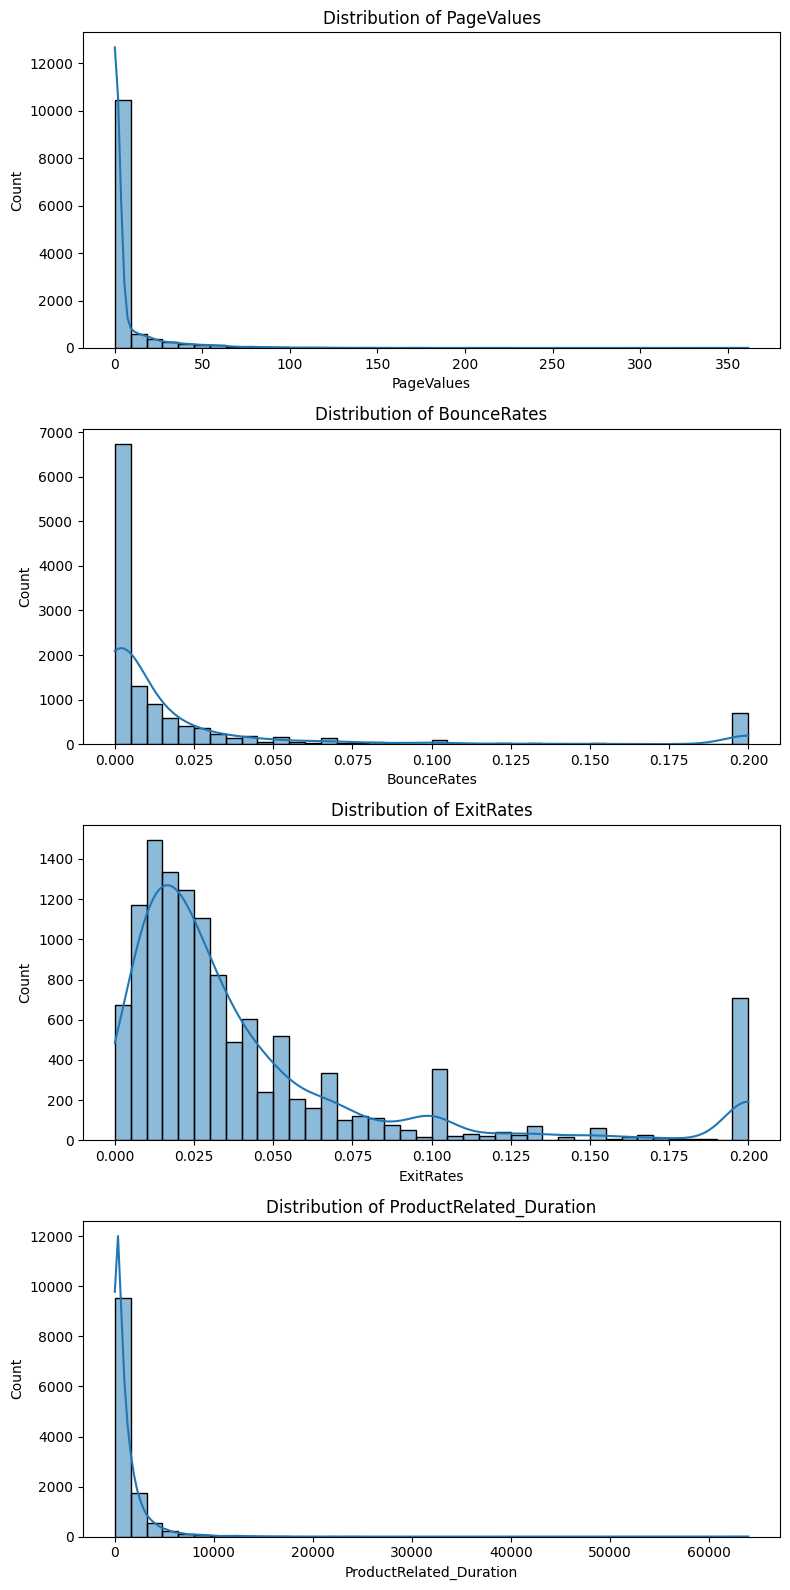

In [20]:
important_numeric = [c for c in ["PageValues", "BounceRates", "ExitRates", "ProductRelated_Duration"] if c in df.columns]

fig, axes = plt.subplots(len(important_numeric), 1, figsize=(8, 4*len(important_numeric)))
if len(important_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, important_numeric):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

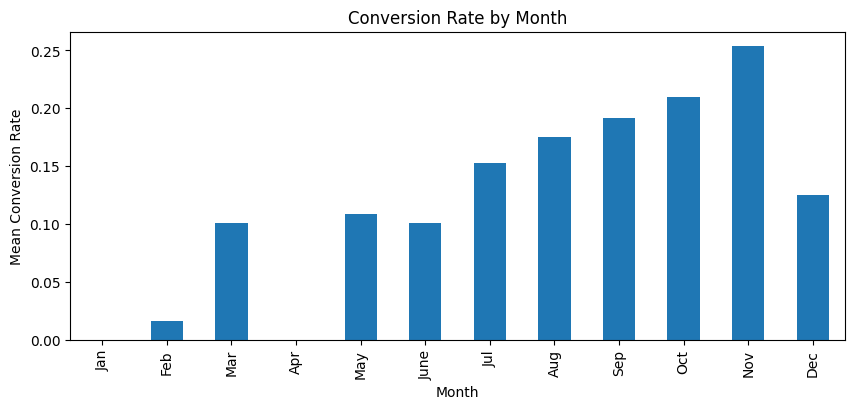

In [21]:
if "Month" in df.columns:
    month_order = ["Jan","Feb","Mar","Apr","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
    temp = df.copy()
    temp["Month"] = pd.Categorical(temp["Month"], categories=month_order, ordered=True)
    conv_by_month = temp.groupby("Month", observed=False)["Revenue"].mean()
    plt.figure(figsize=(10,4))
    conv_by_month.plot(kind="bar")
    plt.title("Conversion Rate by Month")
    plt.ylabel("Mean Conversion Rate")
    plt.show()

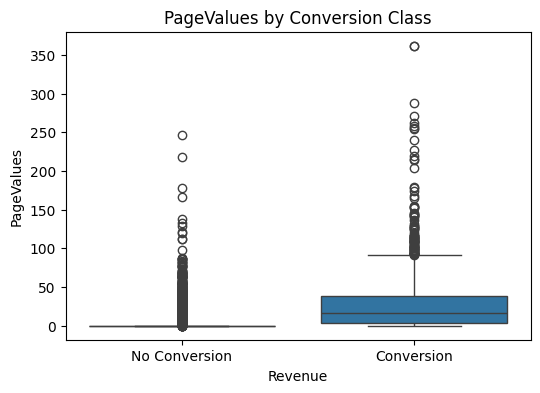

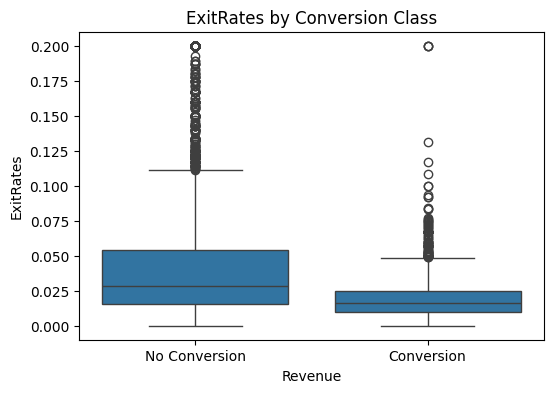

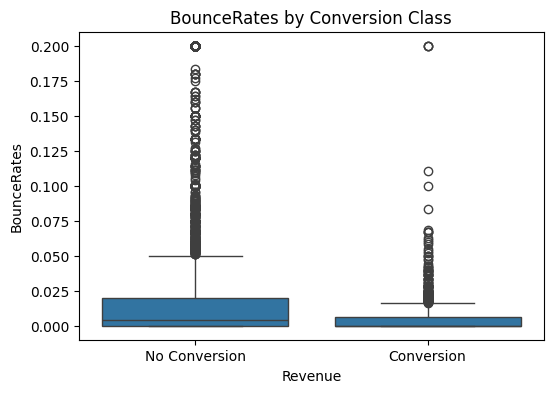

In [22]:
for col in [c for c in ["PageValues", "ExitRates", "BounceRates"] if c in df.columns]:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Revenue", y=col)
    plt.title(f"{col} by Conversion Class")
    plt.xticks([0,1], ["No Conversion", "Conversion"])
    plt.show()

## 4. Feature groups for the ablation study
We separate:
- **Behavioral features**: browsing/session interaction signals
- **Temporal features**: time context such as month/weekend

In [23]:
behavioral_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
    "OperatingSystems", "Browser", "Region", "TrafficType",
    "VisitorType"
]

temporal_features = ["Month", "Weekend"]

behavioral_features = [c for c in behavioral_features if c in df.columns]
temporal_features = [c for c in temporal_features if c in df.columns]

target_col = "Revenue"

print("Behavioral features:", behavioral_features)
print("Temporal features:", temporal_features)
print("Target:", target_col)

Behavioral features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']
Temporal features: ['Month', 'Weekend']
Target: Revenue


## 5. Preprocessing helpers
We:
- split train/test with stratification
- apply log transform to skewed numeric features
- one-hot encode categorical variables
- apply SMOTE **only on training data**

In [24]:
def infer_feature_types(X: pd.DataFrame):
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    # Treat low-cardinality boolean-like integer columns as categorical only if originally non-numeric categories are absent
    numeric_cols = [c for c in X.columns if c not in categorical_cols]
    return numeric_cols, categorical_cols

def safe_log1p(X):
    X = np.asarray(X, dtype=float)
    return np.log1p(np.clip(X, a_min=0, a_max=None))

def build_preprocessor(X: pd.DataFrame):
    numeric_cols, categorical_cols = infer_feature_types(X)

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(safe_log1p, feature_names_out="one-to-one"))
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_cols, categorical_cols

def make_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            random_state=SEED,
            class_weight="balanced_subsample"
        ),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=SEED,
            eval_metric="logloss",
            n_jobs=2
        )
    }

## 6. Training and evaluation function
This function trains the 3 models and returns:
- fitted pipelines
- metrics
- predictions

In [25]:
def train_and_evaluate(df, feature_cols, target_col="Revenue", test_size=0.2):
    X = df[feature_cols].copy()
    y = df[target_col].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=SEED
    )

    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)
    models = make_models()

    rows = []
    fitted = {}

    for model_name, model in models.items():
        pipe = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=SEED)),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            y_score = y_pred.astype(float)

        rows.append({
            "Model": model_name,
            "F1": f1_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "AUPRC": average_precision_score(y_test, y_score),
            "ROC_AUC": roc_auc_score(y_test, y_score)
        })

        fitted[model_name] = {
            "pipeline": pipe,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_score": y_score,
            "numeric_cols": numeric_cols,
            "categorical_cols": categorical_cols
        }

    result_df = pd.DataFrame(rows).sort_values(by=["F1", "AUPRC"], ascending=False).reset_index(drop=True)
    return result_df, fitted

## 7. Main experiment: all selected features
This is the primary comparison across Logistic Regression, Random Forest, and XGBoost.

In [26]:
all_features = behavioral_features + temporal_features
results_main, fitted_main = train_and_evaluate(df, all_features, target_col=target_col)
results_main

,Model,F1,Precision,Recall,AUPRC,ROC_AUC
0,Random Forest,0.650169,0.570020,0.756545,0.693646,0.921820
1,Logistic Regression,0.637339,0.540000,0.777487,0.638016,0.916642
2,XGBoost,0.632979,0.643243,0.623037,0.721496,0.927068


In [27]:
best_model_name = results_main.iloc[0]["Model"]
best_info = fitted_main[best_model_name]

print("Best model:", best_model_name)
print("\nClassification report:")
print(classification_report(best_info["y_test"], best_info["y_pred"]))

Best model: Random Forest

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2084
           1       0.57      0.76      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.79      2466
weighted avg       0.89      0.87      0.88      2466



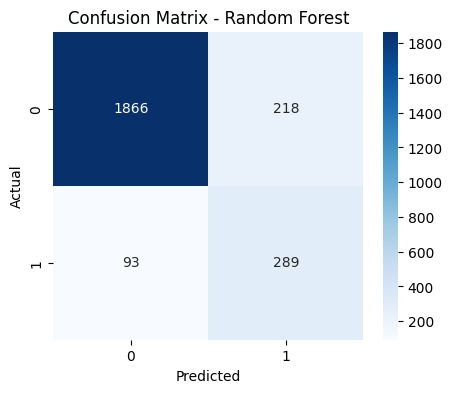

In [28]:
cm = confusion_matrix(best_info["y_test"], best_info["y_pred"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

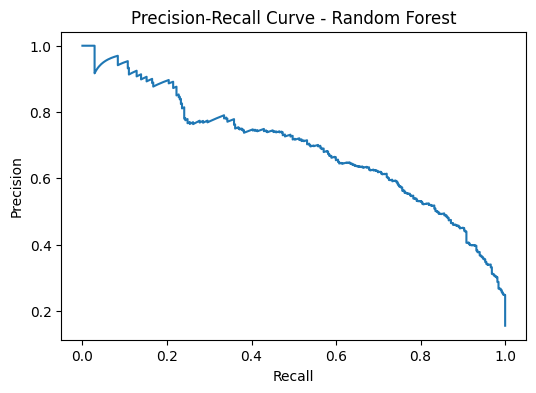

In [29]:
precision, recall, _ = precision_recall_curve(best_info["y_test"], best_info["y_score"])
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 8. Ablation study
We compare:
1. **Behavioral features only**
2. **Behavioral + temporal features**

In [30]:
results_behavioral, fitted_behavioral = train_and_evaluate(df, behavioral_features, target_col=target_col)
results_full, fitted_full = train_and_evaluate(df, behavioral_features + temporal_features, target_col=target_col)

print("Behavioral only")
display(results_behavioral)

print("Behavioral + Temporal")
display(results_full)

Behavioral only


,Model,F1,Precision,Recall,AUPRC,ROC_AUC
0,Random Forest,0.652826,0.583505,0.740838,0.670327,0.894250
1,XGBoost,0.645333,0.657609,0.633508,0.688861,0.897454
2,Logistic Regression,0.642937,0.558994,0.756545,0.628744,0.883528


Behavioral + Temporal


,Model,F1,Precision,Recall,AUPRC,ROC_AUC
0,Random Forest,0.650169,0.570020,0.756545,0.693646,0.921820
1,Logistic Regression,0.637339,0.540000,0.777487,0.638016,0.916642
2,XGBoost,0.632979,0.643243,0.623037,0.721496,0.927068


In [31]:
ablation_table = pd.DataFrame({
    "Model": results_full["Model"],
    "F1_BehavioralOnly": results_behavioral.set_index("Model").loc[results_full["Model"], "F1"].values,
    "F1_BehavioralPlusTemporal": results_full["F1"].values,
    "AUPRC_BehavioralOnly": results_behavioral.set_index("Model").loc[results_full["Model"], "AUPRC"].values,
    "AUPRC_BehavioralPlusTemporal": results_full["AUPRC"].values,
})
ablation_table["F1_Gain_From_Temporal"] = ablation_table["F1_BehavioralPlusTemporal"] - ablation_table["F1_BehavioralOnly"]
ablation_table["AUPRC_Gain_From_Temporal"] = ablation_table["AUPRC_BehavioralPlusTemporal"] - ablation_table["AUPRC_BehavioralOnly"]
ablation_table

,Model,F1_BehavioralOnly,F1_BehavioralPlusTemporal,AUPRC_BehavioralOnly,AUPRC_BehavioralPlusTemporal,F1_Gain_From_Temporal,AUPRC_Gain_From_Temporal
0,Random Forest,0.652826,0.650169,0.670327,0.693646,-0.002657,0.023319
1,Logistic Regression,0.642937,0.637339,0.628744,0.638016,-0.005598,0.009271
2,XGBoost,0.645333,0.632979,0.688861,0.721496,-0.012355,0.032635


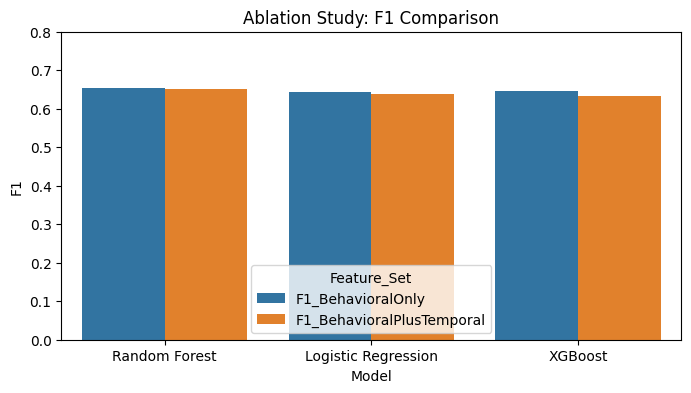

In [32]:
plt.figure(figsize=(8,4))
plot_df = ablation_table.melt(
    id_vars="Model",
    value_vars=["F1_BehavioralOnly", "F1_BehavioralPlusTemporal"],
    var_name="Feature_Set",
    value_name="F1"
)
sns.barplot(data=plot_df, x="Model", y="F1", hue="Feature_Set")
plt.title("Ablation Study: F1 Comparison")
plt.ylim(0, max(0.8, plot_df["F1"].max() + 0.05))
plt.show()

## 9. SHAP interpretability for XGBoost
We explain the best XGBoost model from the **Behavioral + Temporal** setting.

In [33]:
# Reuse the XGBoost model from the full feature setting
xgb_info = fitted_full["XGBoost"]
xgb_pipe = xgb_info["pipeline"]
X_test_full = xgb_info["X_test"]

preprocessor = xgb_pipe.named_steps["preprocessor"]
xgb_model = xgb_pipe.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test_full)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed shape: (2466, 28)
Number of feature names: 28


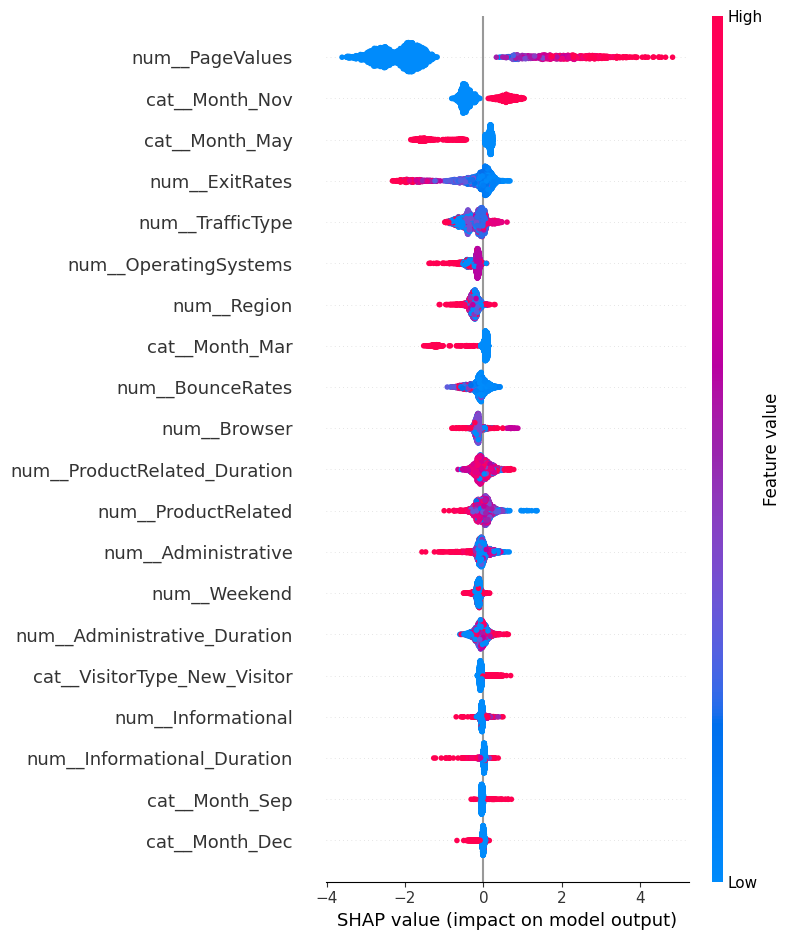

In [34]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [35]:
# Optional: top SHAP features as a table
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
8,num__PageValues,2.138168
25,cat__Month_Nov,0.486175
24,cat__Month_May,0.476941
7,num__ExitRates,0.365135
13,num__TrafficType,0.279472
10,num__OperatingSystems,0.253740
12,num__Region,0.241970
23,cat__Month_Mar,0.226532
6,num__BounceRates,0.173964
11,num__Browser,0.167688


## 10. Save results for report and presentation
These files can be uploaded to GitHub and used in your final report.

In [36]:
Path("results").mkdir(exist_ok=True)

results_main.to_csv("results/main_model_results.csv", index=False)
results_behavioral.to_csv("results/behavioral_only_results.csv", index=False)
results_full.to_csv("results/behavioral_plus_temporal_results.csv", index=False)
ablation_table.to_csv("results/ablation_results.csv", index=False)
shap_importance.to_csv("results/shap_feature_importance.csv", index=False)

print("Saved CSV results in /results")

Saved CSV results in /results


## 11. Report-ready interpretation prompts
Use these prompts after you run the notebook and fill in the actual values:

### Main model comparison
- Which model achieved the highest F1-score?
- Did XGBoost outperform Logistic Regression and Random Forest?
- Did the best model satisfy the success criterion of **F1 > 0.65**?

### Ablation study
- Did temporal features improve F1 and AUPRC?
- Which models benefited most from adding Month and Weekend?

### SHAP analysis
- Which features had the highest SHAP importance?
- Do the most important features align with your systems-engineering interpretation of user intent?

### Conclusion template
- The best performing model was ______.
- Adding temporal features changed F1 from ______ to ______.
- The most influential conversion-related features were ______.

## 12. Optional next improvements
If you want to strengthen the final report, add:
- Hyperparameter tuning with cross-validation
- Threshold tuning for F1 optimization
- Calibration analysis
- More visualizations (ROC curve, PR curve for each model)
- Error analysis for false positives vs false negatives